# RQ2 — Implementation Practices (Q17–Q20)

**Analysis to Address RQ2**: Q17–Q20 — how data quality is incorporated into development, how its impact is measured, how often requirements are formally discussed, and how issues are documented and communicated.

In [62]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
TABLES.mkdir(exist_ok=True)

df = U.load_anonymized()
print(f"N={len(df)}")


N=56


In [63]:
Q17_OPTIONS = {
    "q17_initial_eval": [
        "Avaliação inicial durante a coleta e preparação de dados",
        "Initial assessment during data collection and preparation",
    ],
    "q17_continuous_mon": [
        "Monitoramento contínuo durante todo o ciclo de vida do modelo",
        "Continuous monitoring throughout the model's life cycle",
    ],
    "q17_test_sets": [
        "Conjuntos de testes são aplicados para validar a consistência, completude e precisão dos dados antes de serem usados no treinamento.",
        "Test sets are applied to validate the consistency, completeness and accuracy of the data before it is used for training.",
    ],
    "q17_no_strategy": [
        "Não existe uma estratégia formal para assegurar a qualidade dos dados durante o desenvolvimento.",
        "There is no formal strategy to ensure data quality during development.",
        "There is no formal strategy for ensuring data quality during development",
        "There is no formal strategy for ensuring data quality during development.",
    ],
}
Q17_LABELS = {
    "q17_initial_eval": "Initial assessment in collection/preparation",
    "q17_continuous_mon": "Continuous monitoring across lifecycle",
    "q17_test_sets": "Test sets before training",
    "q17_no_strategy": "No formal strategy",
}

Q18_OPTIONS = {
    "q18_ab_tests": ["Testes A/B", "A/B testing"],
    "q18_perf_metrics": [
        "Análise de métricas de performance (ex.: precisão, recall)",
        "Analysis of performance metrics (e.g. precision, recall)",
    ],
    "q18_manual_review": ["Revisão manual dos resultados", "Manual review of results"],
}
Q18_LABELS = {
    "q18_ab_tests": "A/B testing",
    "q18_perf_metrics": "Performance metrics",
    "q18_manual_review": "Manual review of results",
}

Q20_OPTIONS = {
    "q20_structured_text": ["Linguagem estruturada (texto)", "Structured language (text)"],
    "q20_pm_tools": [
        "Ferramentas de Gerenciamento de Projetos (Jira, Trello ou Asana)",
        "Project management tools (Jira, Trello or Asana)",
    ],
    "q20_central_docs": [
        "Documentação Centralizada (Sistemas como Confluence, Google Docs ou Notion)",
        "Centralized documentation (systems such as Confluence, Google Docs or Notion)",
        "Confluence",
    ],
    "q20_alignment_meet": ["Reuniões de Alinhamento", "Alignment meetings"],
    "q20_periodic_reports": ["Relatórios Periódicos", "Periodic reports"],
}
Q20_LABELS = {
    "q20_structured_text": "Structured language",
    "q20_pm_tools": "Project management tools",
    "q20_central_docs": "Centralized documentation",
    "q20_alignment_meet": "Alignment meetings",
    "q20_periodic_reports": "Periodic reports",
}

In [64]:
rng = np.random.default_rng(42)

def _boot_ci(
    values: np.ndarray,
    threshold: int = 4,
    n_bootstrap: int = 1000,
    ci_level: float = 0.95,
) -> tuple[float, float]:
    """Percentile bootstrap CI for the proportion of values >= threshold.

    Parameters
    ----------
    values      : 1-D array of observed values (int or bool/0-1)
    threshold   : values >= threshold count as "success" (default 4, Likert top-box)
                  For binary 0/1 arrays pass threshold=1.
    n_bootstrap : number of bootstrap resamples (default 2000)
    ci_level    : confidence level (default 0.95 → 95% CI)

    Returns
    -------
    (lo, hi) proportions in [0, 1]
    """
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return float("nan"), float("nan")

    alpha = 1 - ci_level
    boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
    boot_props = np.mean(values[boot_indices] >= threshold, axis=1)
    lo = np.percentile(boot_props, 100 * alpha / 2)
    hi = np.percentile(boot_props, 100 * (1 - alpha / 2))
    return lo, hi

In [65]:
def parse_checkboxes(series: pd.Series, options: dict) -> tuple[pd.DataFrame, pd.Series]:
    """For each response, marks True if *any* alias (PT/EN) of the option appears
    as a substring. `options` accepts `{key: str}` or `{key: list[str]}`.
    Returns (binary df, series with residual text after removing the options)."""
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, raw in options.items():
        labels = [raw] if isinstance(raw, str) else list(raw)
        present = pd.Series(False, index=series.index)
        for lab in labels:
            present = present | series.fillna("").str.contains(lab, regex=False)
            residual = residual.fillna("").str.replace(lab, "", regex=False)
        binary[key] = present
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.str.replace(r"^[,\.]\s*", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual


def proportions_with_ci(binary: pd.DataFrame, labels: dict[str, str], n_total: int) -> pd.DataFrame:
    rows = []
    for key in binary.columns:
        vals = binary[key].astype(int).values
        lo, hi = _boot_ci(vals)
        rows.append({
            "key": key,
            "label": labels[key],
            "n": int(binary[key].sum()),
            "pct": binary[key].mean() * 100,
            "ci_lo": lo * 100,
            "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

In [66]:
q17_bin, q17_res = parse_checkboxes(df["incorporation_open"], Q17_OPTIONS)
q18_bin, q18_res = parse_checkboxes(df["measurement_open"], Q18_OPTIONS)
q20_bin, q20_res = parse_checkboxes(df["documentation_open"], Q20_OPTIONS)

n_q17 = df["incorporation_open"].notna().sum()
n_q18 = df["measurement_open"].notna().sum()
n_q20 = df["documentation_open"].notna().sum()

for q, name, n in [(q17_bin, "Q17", n_q17), (q18_bin, "Q18", n_q18), (q20_bin, "Q20", n_q20)]:
    print(f"{name}: n={n}, average options marked = {q.sum(axis=1).mean():.2f}")

q17_bin["q17_other"] = q17_res.str.len() > 0
q18_bin["q18_other"] = q18_res.str.len() > 0
q20_bin["q20_other"] = q20_res.str.len() > 0

Q17_LABELS["q17_other"] = "Other"
Q18_LABELS["q18_other"] = "Other"
Q20_LABELS["q20_other"] = "Other"

Q17: n=56, average options marked = 1.93
Q18: n=56, average options marked = 1.73
Q20: n=56, average options marked = 2.18


In [67]:
q19_bin = pd.DataFrame({
    "q19_never":     df["discussion_freq"] == 1,
    "q19_rarely":    df["discussion_freq"] == 2,
    "q19_sometimes": df["discussion_freq"] == 3,
    "q19_often":     df["discussion_freq"] == 4,
    "q19_always":    df["discussion_freq"] == 5,
})
n_q19 = df["discussion_freq"].notna().sum()
Q19_LABELS = {
    "q19_never":     "Never",
    "q19_rarely":    "<1x/month",
    "q19_sometimes": "1x/month to <1x/week",
    "q19_often":     "≥1x/week",
    "q19_always":    "Daily",
}

p17 = proportions_with_ci(q17_bin, Q17_LABELS, n_q17)
p18 = proportions_with_ci(q18_bin, Q18_LABELS, n_q18)
p19 = proportions_with_ci(q19_bin, Q19_LABELS, n_q19)
p20 = proportions_with_ci(q20_bin, Q20_LABELS, n_q20)

## 2. Parser — converts free text into binary columns

## Q17 + Q18 — Incorporation and Measurement

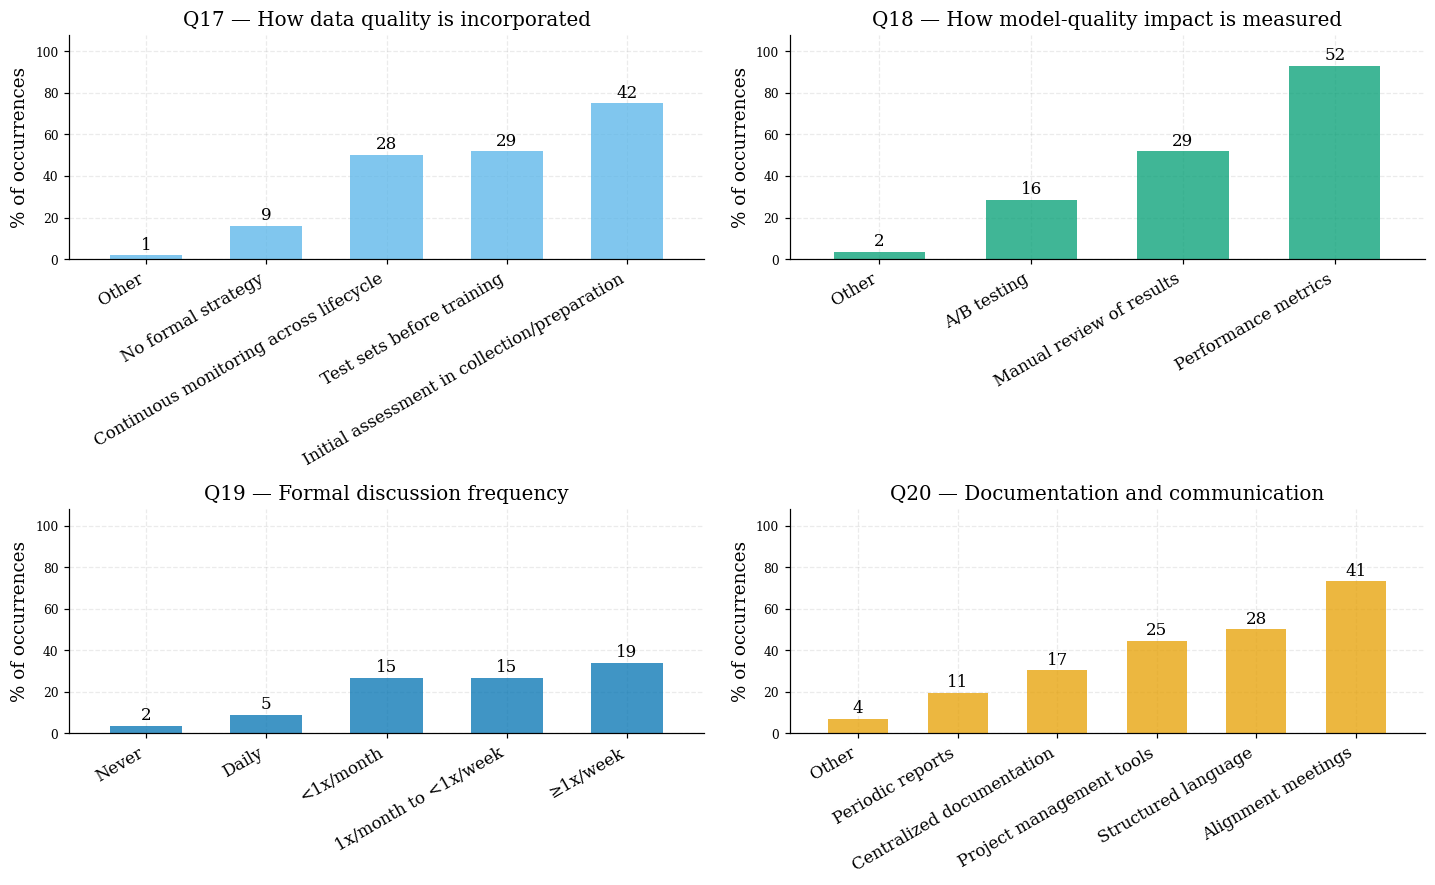

In [68]:
def ci_band_barh_plot(p: pd.DataFrame, title: str, color: str, ax) -> None:
    p_sorted = p.sort_values("pct")
    y = np.arange(len(p_sorted))
    pct = p_sorted["pct"].values
    ci_lo = np.clip(p_sorted["ci_lo"].values, 0, 100)
    ci_hi = np.clip(p_sorted["ci_hi"].values, 0, 100)

    ax.barh(y, pct, color=color, alpha=0.75, height=0.7)
    ax.barh(y, ci_hi - ci_lo, left=ci_lo, color="black", alpha=0.15)

    ax.set_yticks(y)
    ax.set_yticklabels(p_sorted["label"], fontsize=12)

    ax.set_xlim(0, 108)
    ax.set_xlabel("% of occurrences", fontsize=12)
    ax.set_title(title, fontsize=13)

    for i, (v, n) in enumerate(zip(pct, p_sorted["n"])):
        ax.text(min(v + 2, 106), i, f"{int(n)}", va="center", fontsize=11)


def ci_band_barv_plot(p: pd.DataFrame, title: str, color: str, ax) -> None:
    p_sorted = p.sort_values("pct")
    x = np.arange(len(p_sorted))
    pct = p_sorted["pct"].values
    ci_lo = np.clip(p_sorted["ci_lo"].values, 0, 100)
    ci_hi = np.clip(p_sorted["ci_hi"].values, 0, 100)

    ax.bar(x, pct, color=color, alpha=0.75, width=0.6)
    ax.bar(x, ci_hi - ci_lo, bottom=ci_lo, color="black", alpha=0.15)

    ax.set_xticks(x)
    ax.set_xticklabels(p_sorted["label"], rotation=30, ha="right", fontsize=11)

    ax.set_ylim(0, 108)
    ax.set_ylabel("% of occurrences", fontsize=12)
    ax.set_title(title, fontsize=13)

    for i, (v, n) in enumerate(zip(pct, p_sorted["n"])):
        ax.text(i, min(v + 3, 106), f"{int(n)}",
                ha="center", fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(13, 8))

ci_band_barv_plot(
    p17,
    "Q17 — How data quality is incorporated",
    U.PALETTE_WONG[2],
    axes[0, 0]
)

ci_band_barv_plot(
    p18,
    "Q18 — How model-quality impact is measured",
    U.PALETTE_WONG[3],
    axes[0, 1]
)

ci_band_barv_plot(
    p19,
    "Q19 — Formal discussion frequency",
    U.PALETTE_WONG[5],
    axes[1, 0]
)

ci_band_barv_plot(
    p20,
    "Q20 — Documentation and communication",
    U.PALETTE_WONG[1],
    axes[1, 1]
)

fig.tight_layout(pad=0.6, h_pad=1.2, w_pad=2.0)

U.save_fig(fig, "implementation_q17_q20")
plt.show()

## Group comparison heatmap — Q17/Q18/Q20 × demographic subgroups

Heatmap with **per-column normalization**: within each group column the item
with the highest count is the darkest cell, making within-group prominence
immediately visible.

Three comparisons:
- **Discussion frequency**: Frequent (≥ weekly) vs Sporadic (< weekly)
- **Role orientation**: Data-oriented (DS + DE + MLE) vs Product-oriented (Dev + Mgr + Res)
- **Experience**: ≤ 3 projects vs > 3 projects


In [69]:
def four_question_heatmaps(questions_data, comparisons):
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np

    # Fonte sem serifa padrão
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]

    n_q      = len(questions_data)
    n_panels = len(comparisons)

    items_per_q  = [len(bin_df.columns) for _, bin_df, _, _ in questions_data]
    width_ratios = [len(groups) for _, groups in comparisons] + [0.28]  # mais espaço p/ colorbar

    row_h = 0.40
    fig_h = sum(items_per_q) * row_h + 2.4
    fig_w = 11.5

    fig, axes = plt.subplots(
        n_q, n_panels + 1,
        figsize=(fig_w, fig_h),
        gridspec_kw={
            "height_ratios": items_per_q,
            "width_ratios":  width_ratios,
            "wspace": 0.00,  # 👈 empurra colorbar para direita
        },
        squeeze=False,
    )

    cmap = plt.get_cmap("Blues")
    MIN_INTENSITY = 0.05

    for q_idx, (q_label, bin_df, labels, source) in enumerate(questions_data):
        cols         = list(bin_df.columns)
        n_items      = len(cols)
        item_labels_ = [labels.get(c, c) for c in cols]

        global_max = 0
        panel_data = []
        for _, groups in comparisons:
            grp_counts = []
            for _, mask in groups:
                cnts = [int(bin_df.loc[mask, col].sum()) for col in cols]
                grp_counts.append(cnts)
                global_max = max(global_max, max(cnts, default=0))
            panel_data.append(grp_counts)
        if global_max == 0:
            global_max = 1

        for p_idx, (panel_title, groups) in enumerate(comparisons):
            ax       = axes[q_idx, p_idx]
            n_groups = len(groups)
            totals   = [int(mask.sum()) for _, mask in groups]

            raw = np.zeros((n_items, n_groups), dtype=int)
            mat = np.zeros((n_items, n_groups))
            for g_idx, cnts in enumerate(panel_data[p_idx]):
                for i, cnt in enumerate(cnts):
                    raw[i, g_idx] = cnt
                    mat[i, g_idx] = MIN_INTENSITY + (1 - MIN_INTENSITY) * cnt / global_max

            ax.imshow(mat, aspect="auto", cmap=cmap,
                      vmin=0, vmax=1, interpolation="nearest")

            for i in range(n_items):
                for j in range(n_groups):
                    tc = "white" if mat[i, j] > 0.60 else "black"
                    ax.text(j, i, str(raw[i, j]),
                            ha="center", va="center", fontsize=8, color=tc)

            if p_idx == 0:
                ax.set_yticks(range(n_items))
                ax.set_yticklabels(item_labels_, fontsize=8.5)
                ax.text(
                    0.0, 1.04,
                    q_label,
                    transform=ax.transAxes,
                    ha="left", va="bottom",
                    fontsize=9.5,
                    fontweight="bold"
                )
            else:
                ax.set_yticks([])

            ax.set_xticks(range(n_groups))
            ax.set_xticklabels(
                [f"{groups[j][0]}\n(n={totals[j]})" for j in range(n_groups)],
                fontsize=7.5,
            )
            ax.tick_params(left=False, bottom=False)
            for sp in ax.spines.values():
                sp.set_visible(False)

            if q_idx == 0:
                ax.set_title(panel_title, fontsize=10, pad=22)

        # Colorbar
        cax  = axes[q_idx, n_panels]
        sm   = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
        sm.set_array([])
        cbar = fig.colorbar(sm, cax=cax)

        n_ticks   = min(5, global_max + 1)
        tick_vals = np.linspace(0, global_max, n_ticks).astype(int)
        tick_pos  = MIN_INTENSITY + (1 - MIN_INTENSITY) * tick_vals / global_max
        cbar.set_ticks(tick_pos)
        cbar.set_ticklabels([str(v) for v in tick_vals], fontsize=7.5)
        cbar.ax.tick_params(labelsize=7.5)
        cbar.outline.set_edgecolor((0, 0, 0, 0.3)) 

        if q_idx == 0:
            cbar.set_label("Count", fontsize=8, labelpad=4)

    fig.tight_layout(pad=0.5, h_pad=2.5, w_pad=0)
    return fig

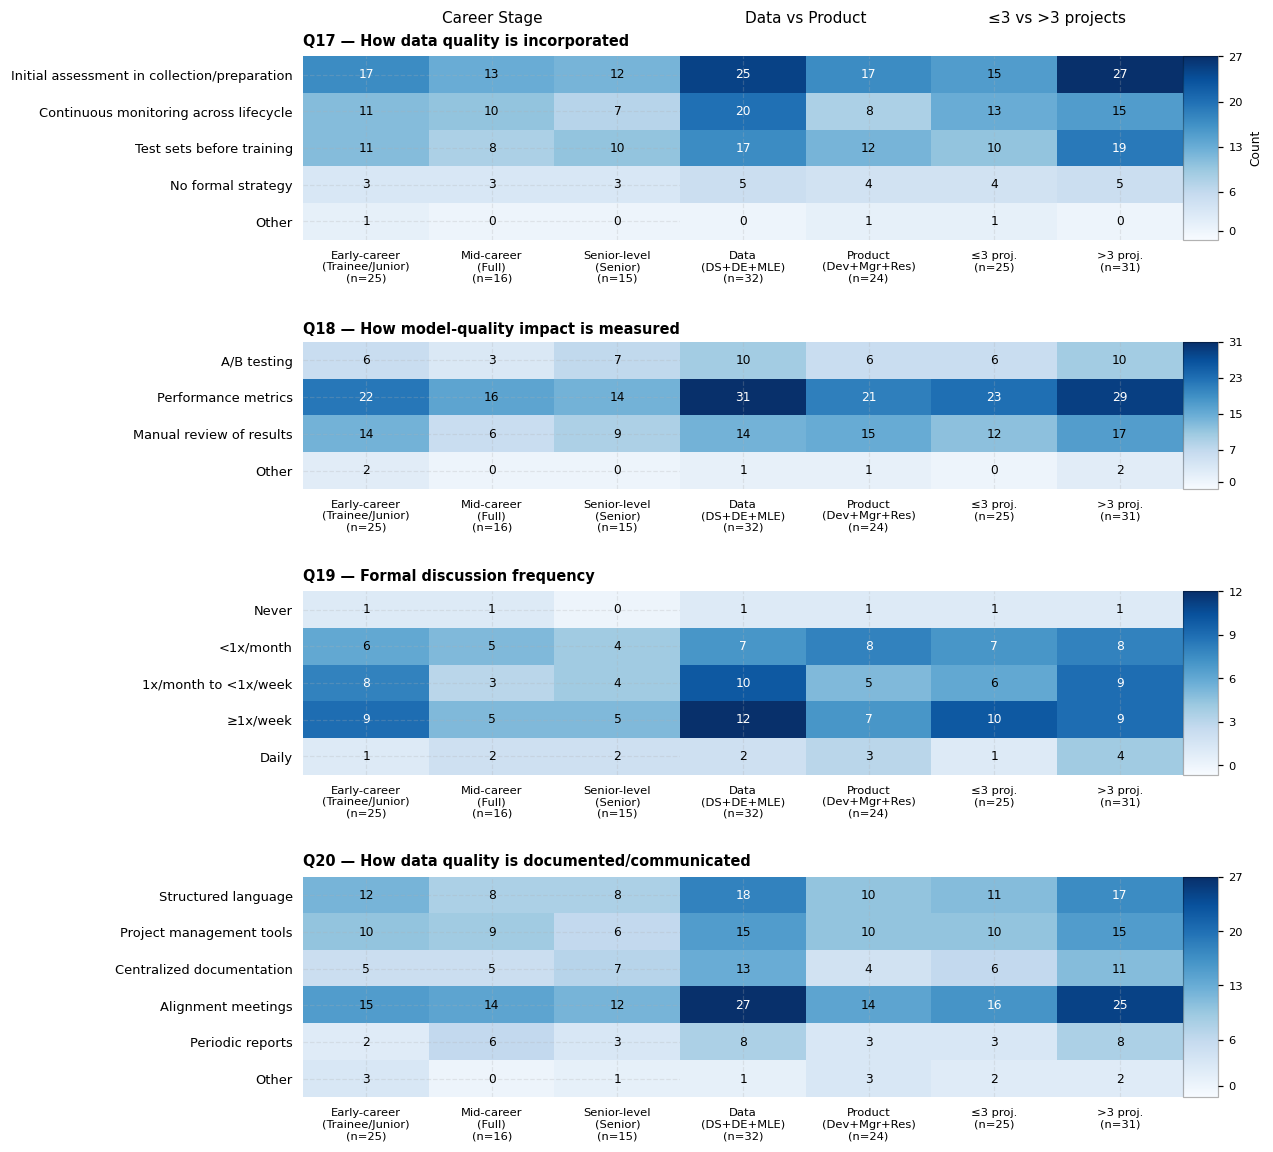

In [70]:
comparisons_heatmap = [
    ("Career Stage", [
        ("Early-career\n(Trainee/Junior)", df["seniority_norm"].isin(["Trainee", "Junior (up to 5 years)"])),
        ("Mid-career\n(Full)",             df["seniority_norm"] == "Full (6 to 9 years)"),
        ("Senior-level\n(Senior)",         df["seniority_norm"] == "Senior (10+ years)"),
    ]),
    ("Data vs Product", [
        ("Data\n(DS+DE+MLE)",      df["role_group"].isin(["Data Scientist", "Data Engineer", "ML Engineer"])),
        ("Product\n(Dev+Mgr+Res)", df["role_group"].isin(["Developer", "Data and AI Manager", "Researcher", "DevOps Engineer", "Tech manager", "Product owner", "Other"])),
    ]),
    ("≤3 vs >3 projects", [
        ("≤3 proj.", df["n_projects"] <= 3),
        (">3 proj.", df["n_projects"] > 3),
    ]),
]

q19_bin = pd.DataFrame({
    "q19_never":     df["discussion_freq"] == 1,
    "q19_rarely":    df["discussion_freq"] == 2,
    "q19_sometimes": df["discussion_freq"] == 3,
    "q19_often":     df["discussion_freq"] == 4,
    "q19_always":    df["discussion_freq"] == 5,
})
n_q19 = df["discussion_freq"].notna().sum()
Q19_LABELS = {
    "q19_never":     "Never",
    "q19_rarely":    "<1x/month",
    "q19_sometimes": "1x/month to <1x/week",
    "q19_often":     "≥1x/week",
    "q19_always":    "Daily",
}

questions_heatmap = [
    ("Q17 — How data quality is incorporated",            q17_bin, Q17_LABELS, df["incorporation_open"]),
    ("Q18 — How model-quality impact is measured",        q18_bin, Q18_LABELS, df["measurement_open"]),
    ("Q19 — Formal discussion frequency",                 q19_bin, Q19_LABELS, df["discussion_freq"]),
    ("Q20 — How data quality is documented/communicated", q20_bin, Q20_LABELS, df["documentation_open"]),
]

fig_hm = four_question_heatmaps(questions_heatmap, comparisons_heatmap)
U.save_fig(fig_hm, "mc_group_heatmap")
plt.show()